                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     63.26
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          2.56e-106
Time:                        20:23:46   Log-Likelihood:                -1070.3
No. Observations:                 392   AIC:                             2183.
Df Residuals:                     371   BIC:                             2266.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.1238     17.718      5.594      0.0

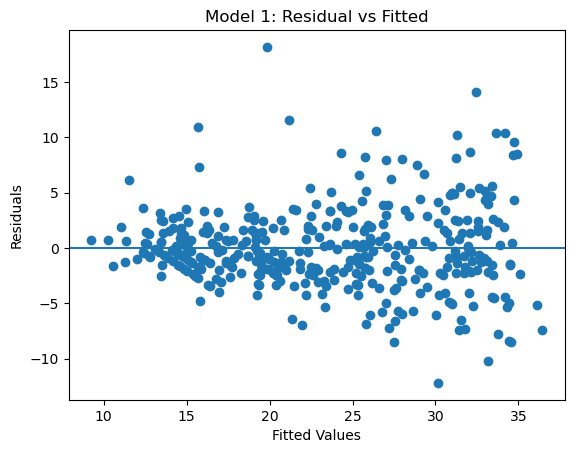

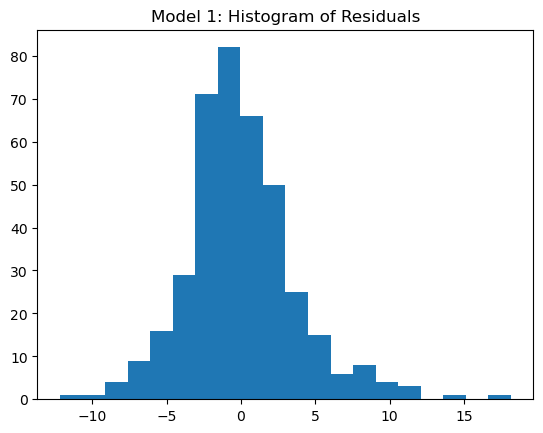

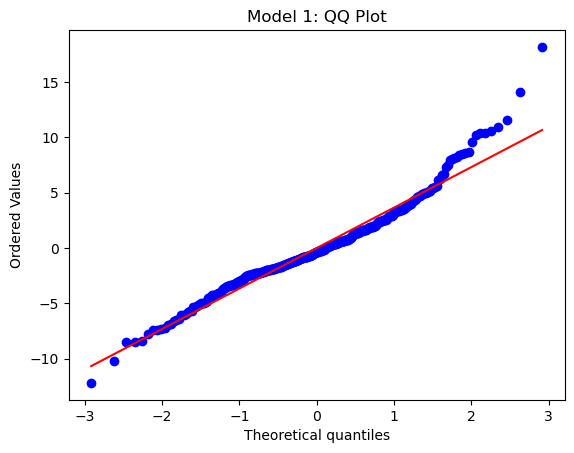

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from scipy import stats

df = pd.read_csv("Auto-1.csv")

df = df.drop(columns=["name"])

y = df["mpg"]

def diagnostic_plots(model, y, title):

    fitted = model.fittedvalues
    residuals = y - fitted

    plt.figure()
    plt.scatter(fitted, residuals)
    plt.axhline(0)
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title(title + ": Residual vs Fitted")
    plt.show()

    plt.figure()
    plt.hist(residuals, bins=20)
    plt.title(title + ": Histogram of Residuals")
    plt.show()

    plt.figure()
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(title + ": QQ Plot")
    plt.show()

X1 = df[["cylinders","displacement","horsepower","weight","acceleration"]]

poly = PolynomialFeatures(degree=2, include_bias=False)

X1_poly = poly.fit_transform(X1)

X1_poly = sm.add_constant(X1_poly)

model1 = sm.OLS(y, X1_poly).fit()

print(model1.summary())

diagnostic_plots(model1, y, "Model 1")

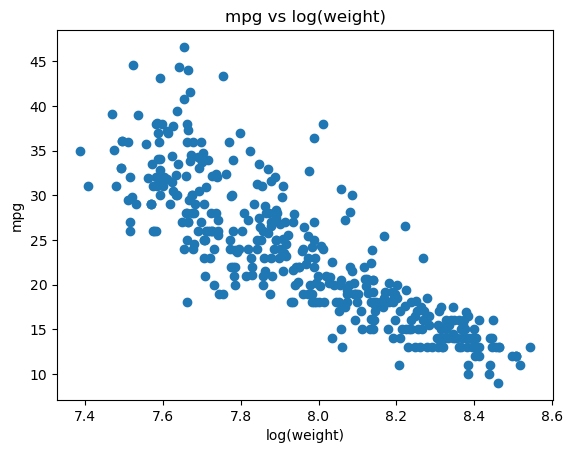

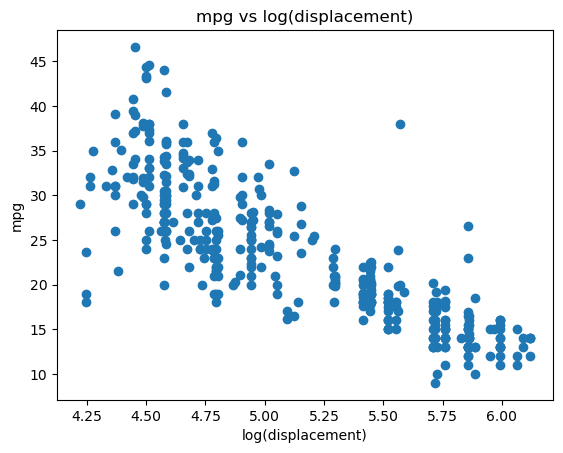

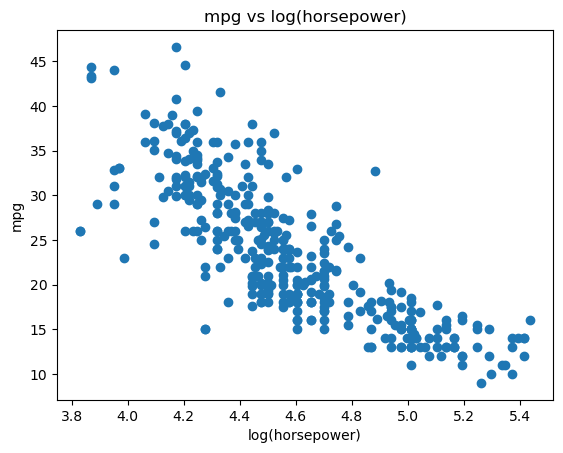

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     229.3
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          3.55e-113
Time:                        20:29:14   Log-Likelihood:                -1090.9
No. Observations:                 392   AIC:                             2194.
Df Residuals:                     386   BIC:                             2218.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              157.1480     12.362  

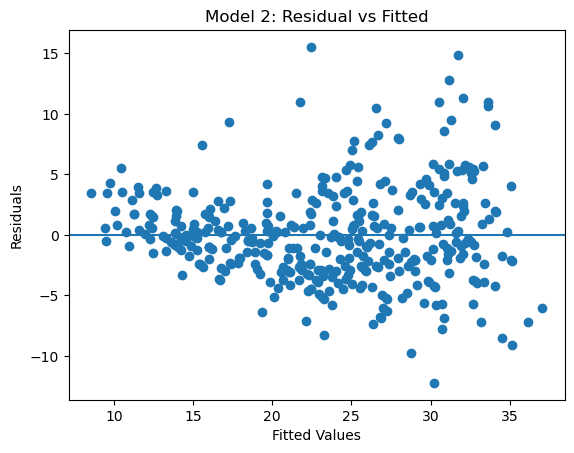

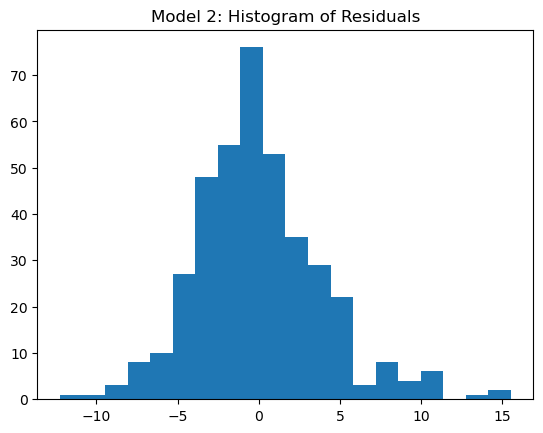

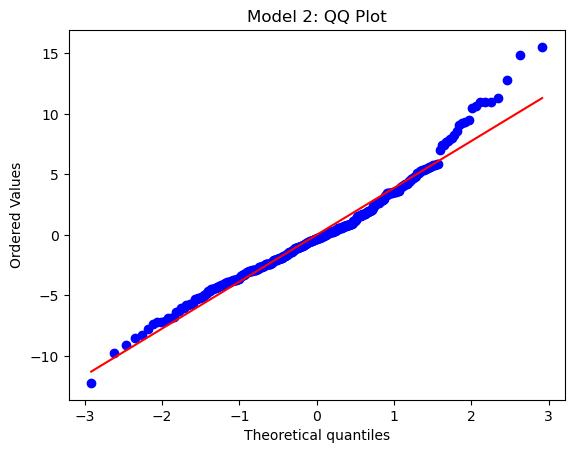

In [5]:
df["log_displacement"] = np.log(df["displacement"])
df["log_horsepower"] = np.log(df["horsepower"])
df["log_weight"] = np.log(df["weight"])

plt.figure()
plt.scatter(df["log_weight"], y)
plt.xlabel("log(weight)")
plt.ylabel("mpg")
plt.title("mpg vs log(weight)")
plt.show()

plt.figure()
plt.scatter(df["log_displacement"], y)
plt.xlabel("log(displacement)")
plt.ylabel("mpg")
plt.title("mpg vs log(displacement)")
plt.show()

plt.figure()
plt.scatter(df["log_horsepower"], y)
plt.xlabel("log(horsepower)")
plt.ylabel("mpg")
plt.title("mpg vs log(horsepower)")
plt.show()

X2 = df[["cylinders","log_displacement","log_horsepower","log_weight","acceleration"]]

X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()

print(model2.summary())

diagnostic_plots(model2, y, "Model 2")

                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     292.9
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          6.18e-129
Time:                        20:37:08   Log-Likelihood:                 174.31
No. Observations:                 392   AIC:                            -336.6
Df Residuals:                     386   BIC:                            -312.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.2203      0.098     42.956   

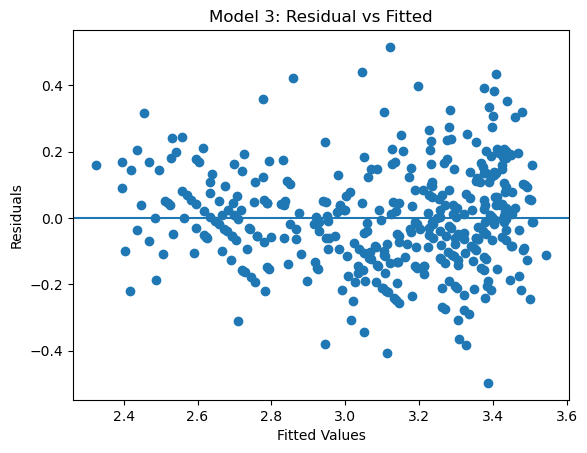

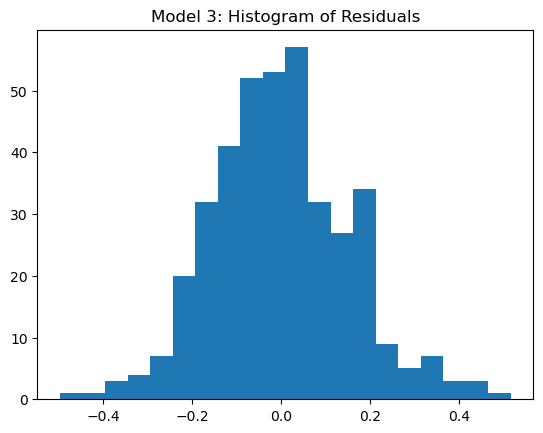

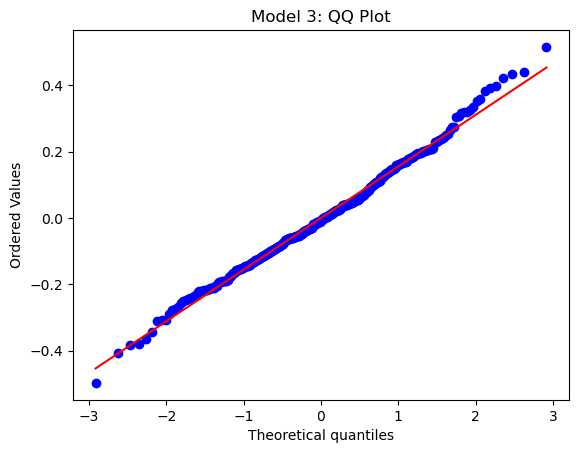

In [6]:
df["log_mpg"] = np.log(df["mpg"])

y3 = df["log_mpg"]

X3 = df[["cylinders","displacement","horsepower","weight","acceleration"]]

X3 = sm.add_constant(X3)

model3 = sm.OLS(y3, X3).fit()

print(model3.summary())

diagnostic_plots(model3, y3, "Model 3")

                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     319.0
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          1.20e-134
Time:                        20:45:44   Log-Likelihood:                 187.69
No. Observations:                 392   AIC:                            -363.4
Df Residuals:                     386   BIC:                            -339.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.7657      0.474  

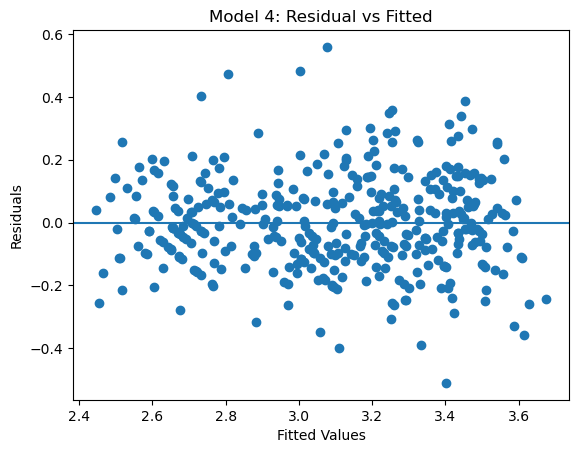

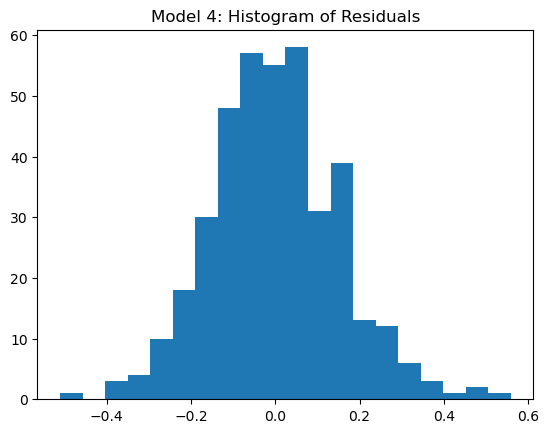

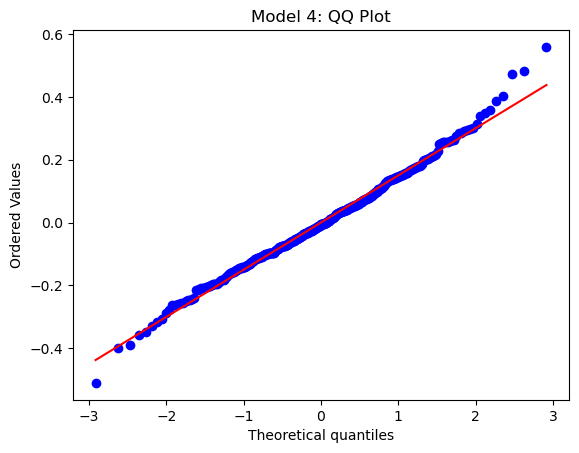

In [9]:
X4 = df[["cylinders","log_displacement","log_horsepower","log_weight","acceleration"]]

X4 = sm.add_constant(X4)

model4 = sm.OLS(y3, X4).fit()

print(model4.summary())

diagnostic_plots(model4, y3, "Model 4")

In [3]:
mpg_boxcox, lambda_opt = stats.boxcox(df["mpg"])

df["mpg_boxcox"] = mpg_boxcox

y5 = df["mpg_boxcox"]

X5 = df[["cylinders","log_displacement","log_horsepower","log_weight","acceleration"]]

X5 = sm.add_constant(X5)

model5 = sm.OLS(y5, X5).fit()

print("\nOptimal Lambda for Box-Cox:", lambda_opt)

print(model5.summary())

diagnostic_plots(model5, y5, "Model 5")

NameError: name 'stats' is not defined